In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix

In [ ]:
# Student dataset
data = {
    "Hours_Studied": [1,2,3,4,5,6,7,8,2,6,7,3],
    "Attendance":    [50,55,60,65,70,80,85,90,40,75,88,58],
    "Result":        [0,0,0,0,1,1,1,1,0,1,1,0]  # 0=Fail, 1=Pass
}

In [ ]:
df = pd.DataFrame(data)
df

,Hours_Studied,Attendance,Result
0,1,50,0
1,2,55,0
2,3,60,0
3,4,65,0
4,5,70,1
5,6,80,1
6,7,85,1
7,8,90,1
8,2,40,0
9,6,75,1


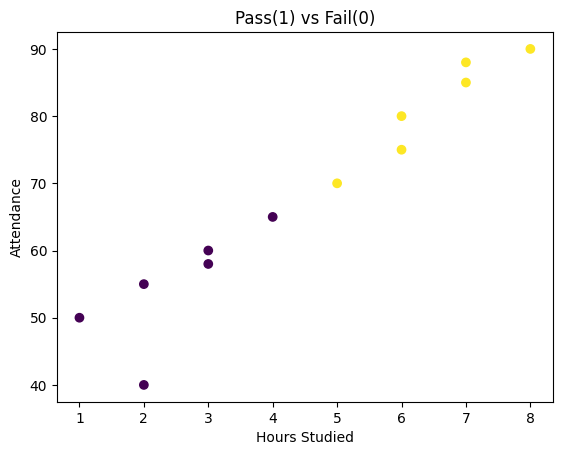

In [ ]:
plt.scatter(df["Hours_Studied"], df["Attendance"], c=df["Result"])
plt.xlabel("Hours Studied")
plt.ylabel("Attendance")
plt.title("Pass(1) vs Fail(0)")
plt.show()

In [ ]:
X = df[["Hours_Studied", "Attendance"]]
y = df["Result"]

In [ ]:
X

,Hours_Studied,Attendance
0,1,50
1,2,55
2,3,60
3,4,65
4,5,70
5,6,80
6,7,85
7,8,90
8,2,40
9,6,75


In [ ]:
model = LogisticRegression()
model.fit(X, y)

LogisticRegression()

In [ ]:
predictions = model.predict(X)
predictions

array([0, 0, 0, 0, 1, 1, 1, 1, 0, 1, 1, 0])

In [ ]:
data

{'Hours_Studied': [1, 2, 3, 4, 5, 6, 7, 8, 2, 6, 7, 3],
 'Attendance': [50, 55, 60, 65, 70, 80, 85, 90, 40, 75, 88, 58],
 'Result': [0, 0, 0, 0, 1, 1, 1, 1, 0, 1, 1, 0]}

In [ ]:
new_student = pd.DataFrame({
    "Hours_Studied":[4],
    "Attendance":[85]
})

model.predict(new_student)

array([1])

In [ ]:
print(model.classes_)
model.predict_proba(new_student)

[0 1]


array([[3.39922863e-06, 9.99996601e-01]])

In [ ]:
accuracy = accuracy_score(y, predictions)
print("Accuracy:", accuracy)

Accuracy: 1.0


In [ ]:
new_student = pd.DataFrame({
    "Hours_Studied":[3],
    "Attendance":[90]
})

model.predict(new_student)

array([1])

In [ ]:
cm = confusion_matrix(y, predictions)
print(cm)

[[6 0]
 [0 6]]


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


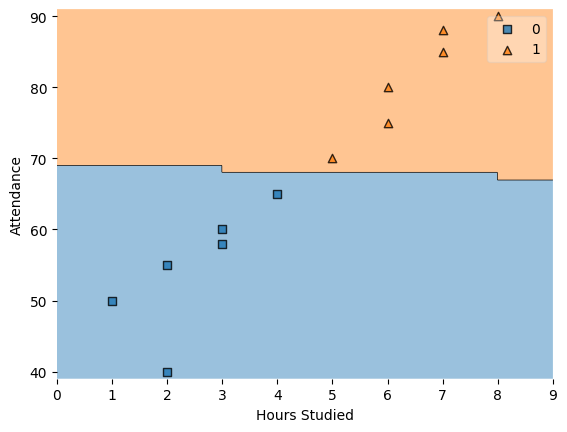

In [ ]:
from mlxtend.plotting import plot_decision_regions

plot_decision_regions(X.values, y.values, clf=model)
plt.xlabel("Hours Studied")
plt.ylabel("Attendance")
plt.show()

---
## 🩺 Logistic Regression: Predicting Categories

Linear Regression predicts a *continuous number* (like House Price).
**Logistic Regression** predicts a *category* (0 or 1, Yes or No).

Instead of a straight line, Logistic Regression uses an **S-Curve (Sigmoid)** to squeeze the predictions between 0 (0%) and 1 (100%).

### 🔬 Real-World Project: Breast Cancer Diagnosis
Let's use the famous Breast Cancer dataset. We will give the AI measurements of a tumor (radius, texture, smoothness) and ask it to predict:
* **0 = Benign** (Not dangerous)
* **1 = Malignant** (Dangerous/Cancerous)

In [ ]:
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

# 1. Load the Breast Cancer dataset
cancer_data = load_breast_cancer()
X = pd.DataFrame(cancer_data.data, columns=cancer_data.feature_names)
y = cancer_data.target  # 0 = Malignant, 1 = Benign
# (Note: Sklearn defaults Malignant=0, Benign=1. We'll leave it as is!)

print("Here are the tumor features the AI will look at:")
display(X.head(3))

# 2. Split into Training (80%) and Testing (20%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

Here are the tumor features the AI will look at:


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,17.99,10.38,122.8,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,25.38,17.33,184.6,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.9,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,24.99,23.41,158.8,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.0,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,23.57,25.53,152.5,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758


### ⚖️ The Secret Step: Feature Scaling
The AI looks at 30 different measurements. Some numbers are tiny (`smoothness = 0.05`) and some are massive (`area = 1000.0`).

If we feed this directly into Logistic Regression, the math engine gets confused and crashes (it fails to "converge"). To fix this, we use a **StandardScaler**. It shrinks all the columns down to the exact same scale so the AI can compare them fairly!

In [ ]:
from sklearn.preprocessing import StandardScaler

# 1. Initialize the Scaler
scaler = StandardScaler()

# 2. FIT (learn the min/max) and TRANSFORM the Training data
X_train_scaled = scaler.fit_transform(X_train)

# 3. ONLY TRANSFORM the Test data (Never fit on the test data!)
X_test_scaled = scaler.transform(X_test)

# 4. Create the Logistic Regression Model
# (Because the data is scaled, we don't even need max_iter=3000 anymore!)
log_model = LogisticRegression()

# 5. Train the model on the SCALED data
log_model.fit(X_train_scaled, y_train)

print("✅ Logistic Regression Model Trained Successfully (Without Warnings)!")

✅ Logistic Regression Model Trained Successfully (Without Warnings)!


AI Diagnostic Accuracy: 97.37%

--- Detailed Diagnostic Report ---
               precision    recall  f1-score   support

Malignant (0)       0.98      0.95      0.96        43
   Benign (1)       0.97      0.99      0.98        71

     accuracy                           0.97       114
    macro avg       0.97      0.97      0.97       114
 weighted avg       0.97      0.97      0.97       114



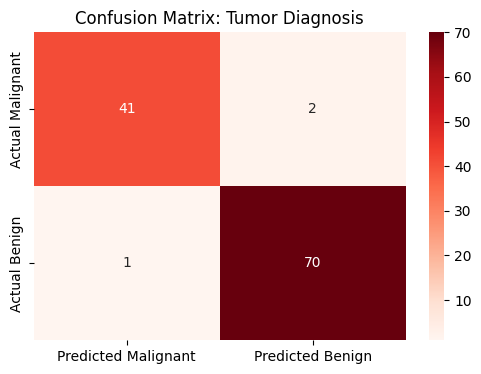

In [ ]:
from sklearn.metrics import classification_report

# 1. Make predictions on the SCALED Test set
predictions = log_model.predict(X_test_scaled)

# 2. Check overall Accuracy
acc = accuracy_score(y_test, predictions)
print(f"AI Diagnostic Accuracy: {acc * 100:.2f}%\n")

# 3. Print the detailed Classification Report
print("--- Detailed Diagnostic Report ---")
# Note: In this sklearn dataset, 0 = Malignant, 1 = Benign
print(classification_report(y_test, predictions, target_names=['Malignant (0)', 'Benign (1)']))

# 4. Visualize the Confusion Matrix
cm = confusion_matrix(y_test, predictions)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Reds',
            xticklabels=['Predicted Malignant', 'Predicted Benign'],
            yticklabels=['Actual Malignant', 'Actual Benign'])
plt.title("Confusion Matrix: Tumor Diagnosis")
plt.show()

### ⚠️ Why is the Confusion Matrix so important here?
In medical AI, **Accuracy is not enough**.
Look at the **False Positives** and **False Negatives**.

* **False Positive (Top-Right):** The AI predicted Benign (Healthy), but the patient actually has a Malignant tumor! (**Extremely Dangerous!**)
* **False Negative (Bottom-Left):** The AI predicted Malignant, but the patient is actually Benign. (Scary for the patient, but doctors will just run more tests).

*Note on Sklearn labels: In this specific dataset, 0 is Malignant and 1 is Benign, which is why our False Positives/Negatives might look visually flipped compared to Class 1. Always check your data labels!*

**As ML Engineers, when building medical AI, our goal is to tune the model so that dangerous mistakes are as close to zero as mathematically possible!**